## 1. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, KFold, cross_val_score
)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    HistGradientBoostingRegressor
)
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

## 2. Data Loading & Inspection

In [4]:
df = pd.read_csv('CAR_DETAILS_FROM_CAR_DEKHO.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (4340, 8)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [6]:
print(df.info())
print('\nMissing values:')
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB
None

Missing values:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64


## 3. EDA

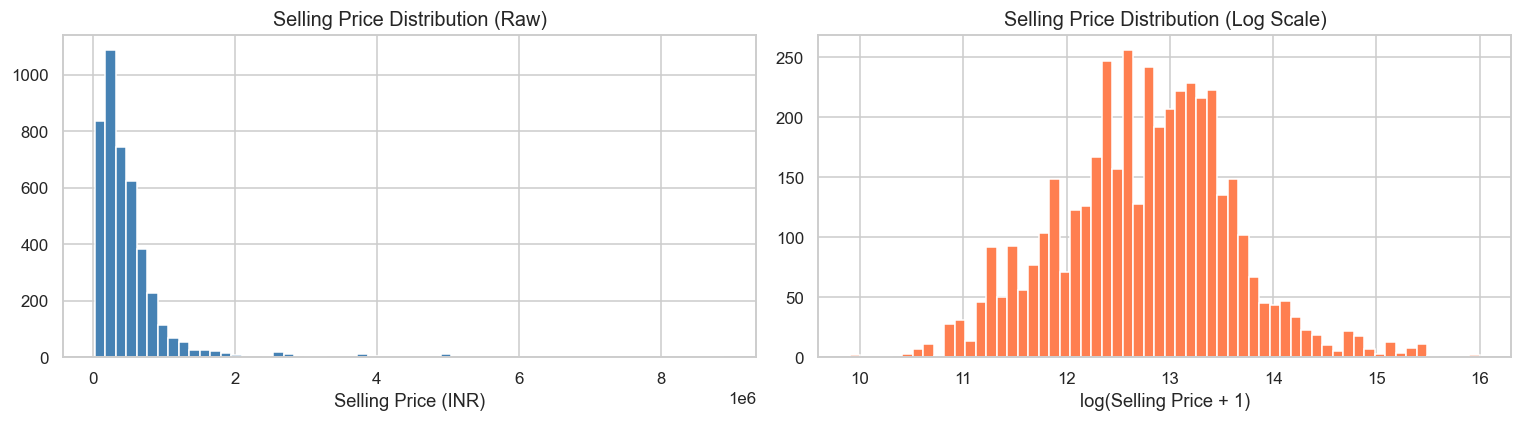

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['selling_price'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Selling Price Distribution (Raw)', fontsize=13)
axes[0].set_xlabel('Selling Price (INR)')
axes[1].hist(np.log1p(df['selling_price']), bins=60, color='coral', edgecolor='white')
axes[1].set_title('Selling Price Distribution (Log Scale)', fontsize=13)
axes[1].set_xlabel('log(Selling Price + 1)')
plt.tight_layout()
plt.savefig('eda_price_distribution.png', bbox_inches='tight')
plt.show()


Insight: Price sangat right-skewed log-transform wajib untuk linear models

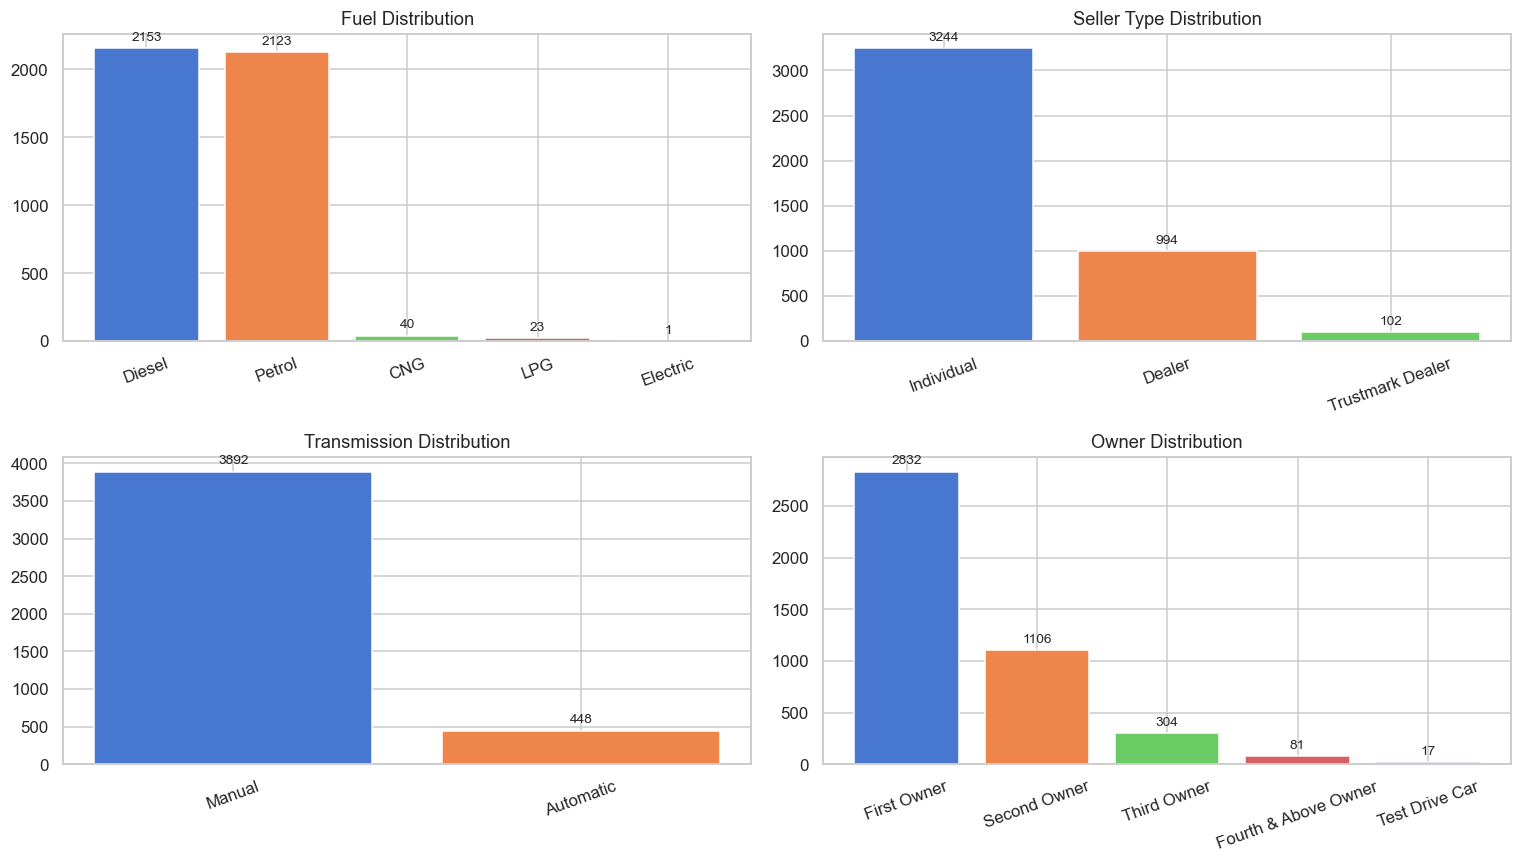

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flatten(), ['fuel', 'seller_type', 'transmission', 'owner']):
    counts = df[col].value_counts()
    bars = ax.bar(counts.index, counts.values,
                  color=sns.color_palette('muted', len(counts)))
    ax.bar_label(bars, padding=3, fontsize=9)
    ax.set_title(f'{col.replace("_"," ").title()} Distribution', fontsize=12)
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('eda_categorical.png', bbox_inches='tight')
plt.show()

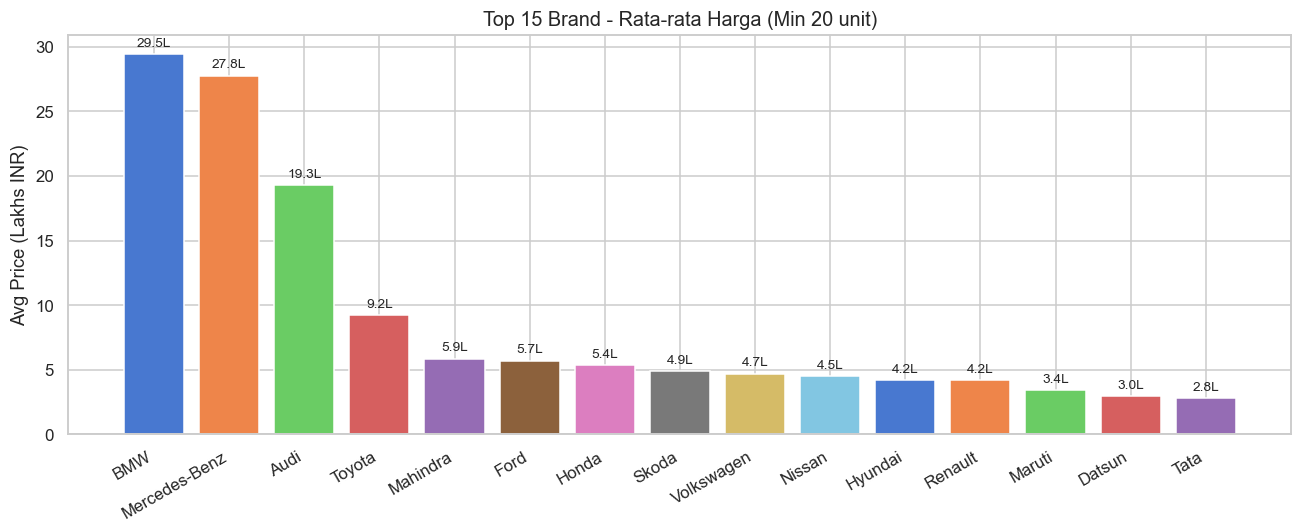

In [10]:
# Top 15 brands by average selling price
df['brand'] = df['name'].str.split().str[0]
brand_price = df.groupby('brand')['selling_price'].agg(['mean','count'])
brand_price = brand_price[brand_price['count'] >= 20].sort_values('mean', ascending=False).head(15)

plt.figure(figsize=(12, 5))
bars = plt.bar(brand_price.index, brand_price['mean']/1e5,
               color=sns.color_palette('muted', len(brand_price)))
plt.bar_label(bars, labels=[f'{v:.1f}L' for v in brand_price['mean']/1e5], padding=3, fontsize=9)
plt.title('Top 15 Brand - Rata-rata Harga (Min 20 unit)', fontsize=13)
plt.ylabel('Avg Price (Lakhs INR)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('eda_brand_price.png', bbox_inches='tight')
plt.show()
df.drop('brand', axis=1, inplace=True)

## 4. Raw Feature Engineering

In [11]:
df_proc = df.copy()

# 1. Extract brand+model (2 kata pertama) - hanya feature creation, belum encoding
df_proc['brand_model'] = df_proc['name'].apply(lambda x: ' '.join(x.split()[:2]))

# 2. Time-based feature (rumus deterministik, tidak butuh fit)
df_proc['car_age'] = 2025 - df_proc['year']
df_proc.drop(['name', 'year'], axis=1, inplace=True)

# 3. Remove extreme outliers - harusnya aman dilakukan sebelum split
#    karena hanya membersihkan data ekstrem, bukan fitting statistik ke target
q99_km = df_proc['km_driven'].quantile(0.99)
q99_pr = df_proc['selling_price'].quantile(0.99)
before = df_proc.shape[0]
df_proc = df_proc[
    (df_proc['km_driven'] <= q99_km) &
    (df_proc['selling_price'] <= q99_pr)
].copy()
print(f'Outlier removed: {before - df_proc.shape[0]} rows | Remaining: {df_proc.shape[0]}')

# 4. Interaction & ratio features (deterministik)
df_proc['km_per_year'] = df_proc['km_driven'] / (df_proc['car_age'] + 1)
df_proc['age_x_km']   = df_proc['car_age'] * df_proc['km_driven']
print(f'Columns setelah raw engineering: {df_proc.columns.tolist()}')

Outlier removed: 85 rows | Remaining: 4255
Columns setelah raw engineering: ['selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'brand_model', 'car_age', 'km_per_year', 'age_x_km']


brand_model dan owner masih raw string - encoding setelah split!

## 5. Train / Validation / Test Split
> **Penting:** Split data dulu sebelum di-encoding biar ga bocor (data leakage)!

- **Train (60%)**: Buat melatih model & fit encoder.
- **Validation (20%)**: Buat tuning hyperparameter & milih model terbaik.
- **Test (20%)**: Buat evaluasi akhir (bener-bener cuma dipake sekali di akhir).

In [12]:
X = df_proc.drop('selling_price', axis=1)
y_orig = df_proc['selling_price']
y_log  = np.log1p(y_orig)  # Log-transform target

# Step 1: hold-out 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42)
y_test_orig = np.expm1(y_test)

# Step 2: remaining → 75% train + 25% val (= 60/20 of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42)
y_train_orig = np.expm1(y_train)
y_val_orig   = np.expm1(y_val)

# Reset index agar tidak ada masalah pandas index saat assignment
X_train = X_train.reset_index(drop=True)
X_val   = X_val.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)

print(f'Train:      {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Validation: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'Test:       {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)')

Train:      2553 samples (60.0%)
Validation: 851 samples (20.0%)
Test:       851 samples (20.0%)


## 6. Preprocessing
Fit transform cuma di-apply ke data Train, data Val & Test tinggal ngikut transform aja biar ga leak.

Langkah Preprocessing:
- **OrdinalEncoder**: buat kolom `owner` biar urutannya bener (First Owner -> Second Owner -> dst).
- **Frequency Encoding**: buat kolom `brand_model` yang fiturnya banyak banget biar diganti sama frekuensi kemunculannya di training set (biar ga bikin kolom bengkak).
- **One-Hot Encoding**: pake `pd.get_dummies` buat kolom kategori biasa (`fuel`, `seller_type`, `transmission`).

In [13]:
# A. ORDINAL ENCODING untuk 'owner'
#    Fit hanya pada X_train, transform semua split
owner_order = [['Test Drive Car', 'Fourth & Above Owner',
                'Third Owner', 'Second Owner', 'First Owner']]

oe_owner = OrdinalEncoder(
    categories=owner_order,
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

# fit_transform pada train, hanya transform pada val & test
X_train['owner_enc'] = oe_owner.fit_transform(X_train[['owner']])
X_val['owner_enc']   = oe_owner.transform(X_val[['owner']])
X_test['owner_enc']  = oe_owner.transform(X_test[['owner']])

X_train.drop('owner', axis=1, inplace=True)
X_val.drop('owner', axis=1, inplace=True)
X_test.drop('owner', axis=1, inplace=True)
print('OrdinalEncoder fitted on train, applied to all splits')

OrdinalEncoder fitted on train, applied to all splits


In [14]:
# B. FREQUENCY ENCODING untuk 'brand_model'
#    Hitung frekuensi dari X_train saja

# normalize=True -> frekuensi relatif (0-1), lebih stabil antar dataset ukuran berbeda
brand_freq_map = X_train['brand_model'].value_counts(normalize=True)

# fillna(0) untuk brand di val/test yang tidak ada di train
X_train['brand_freq'] = X_train['brand_model'].map(brand_freq_map).fillna(0)
X_val['brand_freq']   = X_val['brand_model'].map(brand_freq_map).fillna(0)
X_test['brand_freq']  = X_test['brand_model'].map(brand_freq_map).fillna(0)

X_train.drop('brand_model', axis=1, inplace=True)
X_val.drop('brand_model', axis=1, inplace=True)
X_test.drop('brand_model', axis=1, inplace=True)

print('Frequency encoding fitted on train, applied to all splits')
print(f'  Brands mapped: {len(brand_freq_map)}')

Frequency encoding fitted on train, applied to all splits
  Brands mapped: 159


In [15]:
# C. ONE-HOT ENCODING untuk kolom nominal
#    pd.get_dummies lalu reindex untuk konsistensi kolom
cat_cols = ['fuel', 'seller_type', 'transmission']

# Encode train dulu untuk dapatkan referensi kolom
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=False, dtype=int)
X_val   = pd.get_dummies(X_val,   columns=cat_cols, drop_first=False, dtype=int)
X_test  = pd.get_dummies(X_test,  columns=cat_cols, drop_first=False, dtype=int)

# reindex val dan test agar kolomnya identik dengan train
# Kategori langka yang hanya muncul di train -> kolom baru diisi 0 di val/test
X_val  = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print('One-Hot Encoding done, columns aligned via reindex')
print(f'Final feature count: {X_train.shape[1]}')
print(f'Train shape:  {X_train.shape}')
print(f'Val shape:    {X_val.shape}')
print(f'Test shape:   {X_test.shape}')
print(f'\nFeatures: {X_train.columns.tolist()}')

One-Hot Encoding done, columns aligned via reindex
Final feature count: 15
Train shape:  (2553, 15)
Val shape:    (851, 15)
Test shape:   (851, 15)

Features: ['km_driven', 'car_age', 'km_per_year', 'age_x_km', 'owner_enc', 'brand_freq', 'fuel_CNG', 'fuel_Diesel', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Dealer', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_Automatic', 'transmission_Manual']


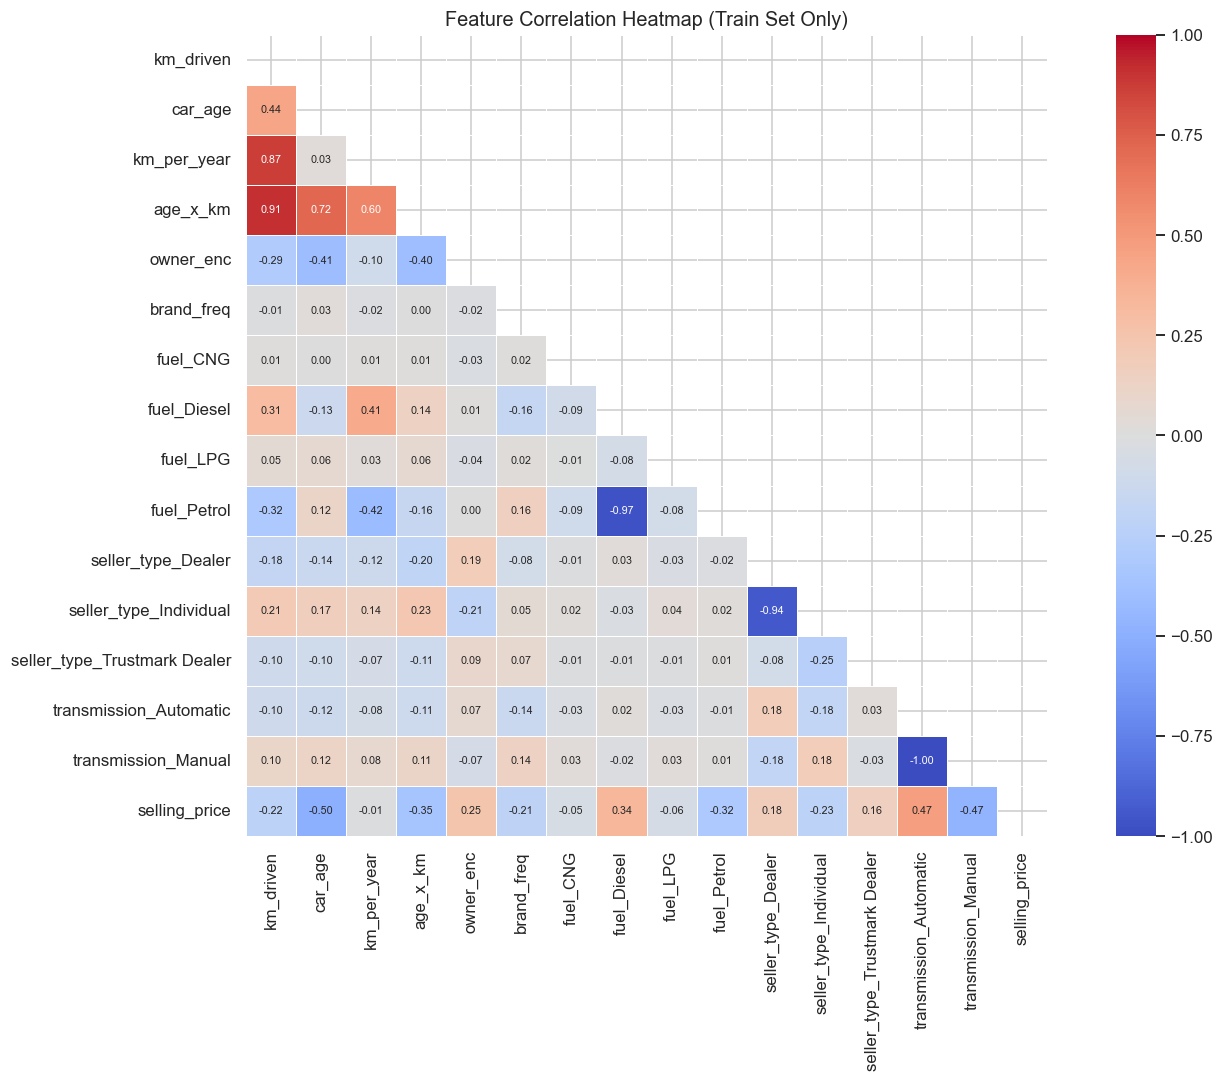

In [16]:
# Correlation heatmap setelah encoding (pakai train saja)
train_for_corr = X_train.copy()
train_for_corr['selling_price'] = y_train_orig.values

plt.figure(figsize=(14, 10))
corr = train_for_corr.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=0.4, annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap (Train Set Only)', fontsize=13)
plt.tight_layout()
plt.savefig('eda_correlation.png', bbox_inches='tight')
plt.show()

## 7. Unified Evaluation Function

In [17]:
def evaluate_model(name, model, X_tr, y_tr, X_vl, y_vl, X_te, y_te,
                   y_tr_orig, y_vl_orig, y_te_orig):
    """
    Model sudah di-fit sebelumnya dalam log-space.
    Fungsi ini hanya evaluate - prediksi log-space lalu inverse ke original scale.
    Returns: (dict of metrics, test predictions in original scale)
    """
    splits = [
        ('Train', X_tr, y_tr, y_tr_orig),
        ('Val',   X_vl, y_vl, y_vl_orig),
        ('Test',  X_te, y_te, y_te_orig),
    ]
    results = {}
    te_pred_orig = None
    for split, Xs, ys_log, ys_orig in splits:
        pred_log  = model.predict(Xs)
        pred_orig = np.expm1(pred_log)
        mae  = mean_absolute_error(ys_orig, pred_orig)
        rmse = np.sqrt(mean_squared_error(ys_orig, pred_orig))
        r2   = r2_score(ys_orig, pred_orig)
        mape = np.mean(np.abs((ys_orig - pred_orig) / (ys_orig + 1))) * 100
        results[split] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}
        if split == 'Test':
            te_pred_orig = pred_orig

    print(f'\n{"="*64}')
    print(f'  {name}')
    print(f'{"="*64}')
    print(f'{"Metric":<8} {"Train":>13} {"Val":>13} {"Test":>13}')
    print(f'{"-"*64}')
    for m in ['MAE','RMSE','R2','MAPE']:
        vals = [results[s][m] for s in ['Train','Val','Test']]
        if m == 'R2':
            print(f'{m:<8} {vals[0]:>13.4f} {vals[1]:>13.4f} {vals[2]:>13.4f}')
        elif m == 'MAPE':
            print(f'{m:<8} {vals[0]:>12.2f}% {vals[1]:>12.2f}% {vals[2]:>12.2f}%')
        else:
            print(f'{m:<8} {vals[0]:>13,.0f} {vals[1]:>13,.0f} {vals[2]:>13,.0f}')
    return results, te_pred_orig

all_results   = {}
all_test_pred = {}
print('evaluate_model ready')

evaluate_model ready


## 8. Model Training & Evaluasi

### 8a. Linear Regression (Baseline)
Model paling simpel buat acuan dasar (lower-bound). Karena targetnya udah di-log-transform, model LR ini secara implisit nangkep hubungan eksponensial di skala aslinya.

In [19]:
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

lin_results, lin_pred = evaluate_model(
    'LINEAR REGRESSION (Baseline)', lin_model,
    X_train, y_train, X_val, y_val, X_test, y_test,
    y_train_orig, y_val_orig, y_test_orig
)
all_results['Linear Regression'] = lin_results
all_test_pred['Linear Regression'] = lin_pred


  LINEAR REGRESSION (Baseline)
Metric           Train           Val          Test
----------------------------------------------------------------
MAE            152,136       170,067       171,536
RMSE           255,180       284,319       298,304
R2              0.5738        0.5867        0.5376
MAPE            37.34%        39.02%        39.45%


In [20]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(LinearRegression(), X_train, y_train, cv=kf, scoring='r2')
print(f'5-Fold CV R2 (log-space): {cv_r2.mean():.4f} +/- {cv_r2.std():.4f}')

5-Fold CV R2 (log-space): 0.6854 +/- 0.0160


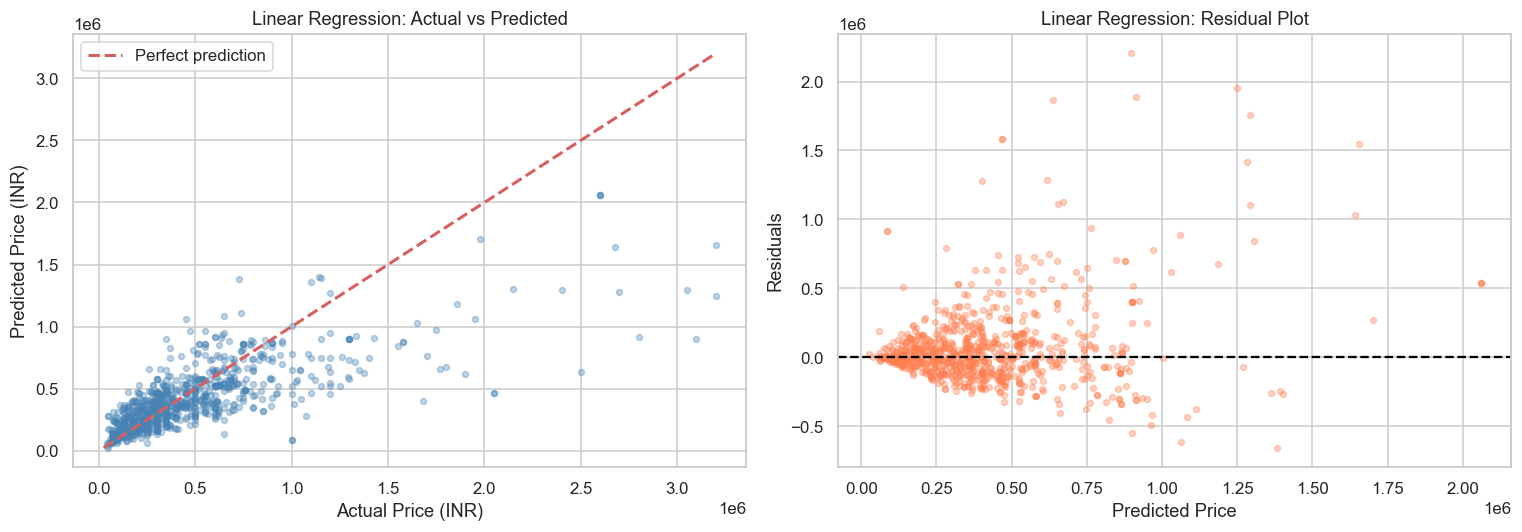

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test_orig, lin_pred, alpha=0.35, color='steelblue', s=15)
lims = [min(y_test_orig.min(), lin_pred.min()), max(y_test_orig.max(), lin_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Perfect prediction')
axes[0].set_title('Linear Regression: Actual vs Predicted')
axes[0].set_xlabel('Actual Price (INR)'); axes[0].set_ylabel('Predicted Price (INR)')
axes[0].legend()

residuals_lin = y_test_orig.values - lin_pred
axes[1].scatter(lin_pred, residuals_lin, alpha=0.35, color='coral', s=15)
axes[1].axhline(0, color='black', lw=1.5, linestyle='--')
axes[1].set_title('Linear Regression: Residual Plot')
axes[1].set_xlabel('Predicted Price'); axes[1].set_ylabel('Residuals')
plt.tight_layout()
plt.savefig('linreg_diagnostics.png', bbox_inches='tight')
plt.show()

### 8b. Ridge Regression (L2 Regularization)
Pake penalti L2 biar bobot fiturnya ga terlalu besar dan ngatasin multikolinearitas (fitur saling berkorelasi). Pake `Ridge(alpha=10)`.

In [23]:
ridge_model = Ridge(alpha=10.0, random_state=42)
ridge_model.fit(X_train, y_train)

ridge_results, ridge_pred = evaluate_model(
    'RIDGE REGRESSION (alpha=10)', ridge_model,
    X_train, y_train, X_val, y_val, X_test, y_test,
    y_train_orig, y_val_orig, y_test_orig
)
all_results['Ridge Regression'] = ridge_results
all_test_pred['Ridge Regression'] = ridge_pred


  RIDGE REGRESSION (alpha=10)
Metric           Train           Val          Test
----------------------------------------------------------------
MAE            153,900       169,783       173,291
RMSE           260,451       289,317       304,636
R2              0.5560        0.5721        0.5178
MAPE            37.30%        38.52%        39.30%


### 8c. Lasso Regression (L1 Regularization)
Pake penalti L1 biar bisa otomatis eliminasi fitur yang ga penting (bobot digeser ke nol). Pake `Lasso(alpha=0.01)` biar ga terlalu agresif motong fiturnya.

In [25]:
lasso_model = Lasso(alpha=0.01, max_iter=5000, random_state=42)
lasso_model.fit(X_train, y_train)

lasso_results, lasso_pred = evaluate_model(
    'LASSO REGRESSION (alpha=0.01)', lasso_model,
    X_train, y_train, X_val, y_val, X_test, y_test,
    y_train_orig, y_val_orig, y_test_orig
)
all_results['Lasso Regression'] = lasso_results
all_test_pred['Lasso Regression'] = lasso_pred

n_zero = np.sum(lasso_model.coef_ == 0)
print(f'\nFitur yang di-zero-out oleh Lasso: {n_zero}/{len(lasso_model.coef_)}')


  LASSO REGRESSION (alpha=0.01)
Metric           Train           Val          Test
----------------------------------------------------------------
MAE            156,331       172,786       178,670
RMSE           271,721       303,845       320,663
R2              0.5167        0.5280        0.4657
MAPE            37.55%        38.80%        39.90%

Fitur yang di-zero-out oleh Lasso: 6/15


### 8d. Random Forest (Baseline)
Pake `RandomForestRegressor` standar. Konsepnya ngambil rata-rata prediksi dari sekumpulan decision tree (bagging).

In [26]:
rf_baseline = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    min_samples_split=10,
    # max_features tidak di-set -> default 1.0 (semua fitur) di sklearn ≥1.1
    random_state=42,
    n_jobs=-1
)
rf_baseline.fit(X_train, y_train)

rf_base_results, rf_base_pred = evaluate_model(
    'RANDOM FOREST (Manual Baseline)', rf_baseline,
    X_train, y_train, X_val, y_val, X_test, y_test,
    y_train_orig, y_val_orig, y_test_orig
)
all_results['Random Forest (Baseline)'] = rf_base_results
all_test_pred['Random Forest (Baseline)'] = rf_base_pred


  RANDOM FOREST (Manual Baseline)
Metric           Train           Val          Test
----------------------------------------------------------------
MAE             95,723       133,711       133,359
RMSE           166,801       232,094       242,105
R2              0.8179        0.7246        0.6954
MAPE            22.97%        30.81%        31.95%


### 8e. Random Forest (Tuned via RandomizedSearchCV)
Tuning hyperparameter pake `RandomizedSearchCV` dengan Cross-Validation. Cara ini jauh lebih cepet dibanding `GridSearchCV` buat nyari kombinasi parameter terbaik di search space yang luas.

In [27]:
param_dist_rf = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [None, 8, 10, 12, 15],    # None = unlimited
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf':  [1, 3, 5, 10],
    'max_features':      [1.0, 0.8, 0.7, 'sqrt'],
}

rf_tuned_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=40,          
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rf_tuned_search.fit(X_train, y_train)

print(f"\nBest params RF: {rf_tuned_search.best_params_}")
print(f"Best CV R2:     {rf_tuned_search.best_score_:.4f}")

rf_tuned = rf_tuned_search.best_estimator_
rf_tuned_results, rf_tuned_pred = evaluate_model(
    'RANDOM FOREST (Tuned)', rf_tuned,
    X_train, y_train, X_val, y_val, X_test, y_test,
    y_train_orig, y_val_orig, y_test_orig
)
all_results['Random Forest (Tuned)'] = rf_tuned_results
all_test_pred['Random Forest (Tuned)'] = rf_tuned_pred

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best params RF: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_depth': 15}
Best CV R2:     0.7928

  RANDOM FOREST (Tuned)
Metric           Train           Val          Test
----------------------------------------------------------------
MAE             47,618       120,289       114,193
RMSE            89,775       225,979       226,868
R2              0.9472        0.7389        0.7326
MAPE            10.99%        27.61%        27.93%


### 8f. Gradient Boosting Regressor
Model boosting sekuensial, tiap tree baru dibikin buat nge-koreksi error dari tree sebelumnya. Biasanya akurasinya lebih bagus daripada Random Forest tapi proses trainingnya agak lebih lama.

In [28]:
gb_model = GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.08, max_depth=5,
    subsample=0.85, min_samples_leaf=5, random_state=42
)
gb_model.fit(X_train, y_train)

gb_results, gb_pred = evaluate_model(
    'GRADIENT BOOSTING', gb_model,
    X_train, y_train, X_val, y_val, X_test, y_test,
    y_train_orig, y_val_orig, y_test_orig
)
all_results['Gradient Boosting'] = gb_results
all_test_pred['Gradient Boosting'] = gb_pred


  GRADIENT BOOSTING
Metric           Train           Val          Test
----------------------------------------------------------------
MAE             58,605       111,825       116,281
RMSE           104,927       214,246       226,677
R2              0.9279        0.7653        0.7330
MAPE            13.80%        26.18%        26.94%


### 8g. HistGradientBoosting (HGBR)
Varian gradient boosting dari scikit-learn yang pake *histogram binning*. Performanya mirip LightGBM atau XGBoost, jauh lebih cepet buat dataset besar.

In [33]:
param_dist_hgbr = {
    'max_iter':           [150, 200, 300],
    'learning_rate':      [0.03, 0.05, 0.08],
    'max_depth':          [3, 4],
    'min_samples_leaf':   [25, 40, 50],
    'l2_regularization':  [1.0, 3.0, 5.0, 10.0],
}

hgbr_search = RandomizedSearchCV(
    HistGradientBoostingRegressor(random_state=42),
    param_distributions=param_dist_hgbr,
    n_iter=20, cv=3, scoring='r2',
    random_state=42, n_jobs=-1, verbose=0
)
hgbr_search.fit(X_train, y_train)

print('Best params HGBR:', hgbr_search.best_params_)
print(f'Best CV R2:       {hgbr_search.best_score_:.4f}')

hgbr_model = hgbr_search.best_estimator_
hgbr_results, hgbr_pred = evaluate_model(
    'HIST GRADIENT BOOSTING (Tuned)', hgbr_model,
    X_train, y_train, X_val, y_val, X_test, y_test,
    y_train_orig, y_val_orig, y_test_orig
)
all_results['HistGradBoost (Tuned)'] = hgbr_results
all_test_pred['HistGradBoost (Tuned)'] = hgbr_pred

Best params HGBR: {'min_samples_leaf': 25, 'max_iter': 300, 'max_depth': 4, 'learning_rate': 0.08, 'l2_regularization': 10.0}
Best CV R2:       0.8117

  HIST GRADIENT BOOSTING (Tuned)
Metric           Train           Val          Test
----------------------------------------------------------------
MAE             89,847       117,937       127,431
RMSE           158,912       215,526       239,157
R2              0.8347        0.7625        0.7028
MAPE            21.05%        27.35%        28.00%


## 9. Error Analysis - Best Model

In [34]:
best_name = max(all_results, key=lambda k: all_results[k]['Test']['R2'])
best_pred = all_test_pred[best_name]
print(f'Best model: {best_name}')
print(f'Test R2:    {all_results[best_name]["Test"]["R2"]:.4f}')
print(f'Test MAE:   {all_results[best_name]["Test"]["MAE"]:,.0f} INR')
print(f'Test MAPE:  {all_results[best_name]["Test"]["MAPE"]:.2f}%')

Best model: Gradient Boosting
Test R2:    0.7330
Test MAE:   116,281 INR
Test MAPE:  26.94%


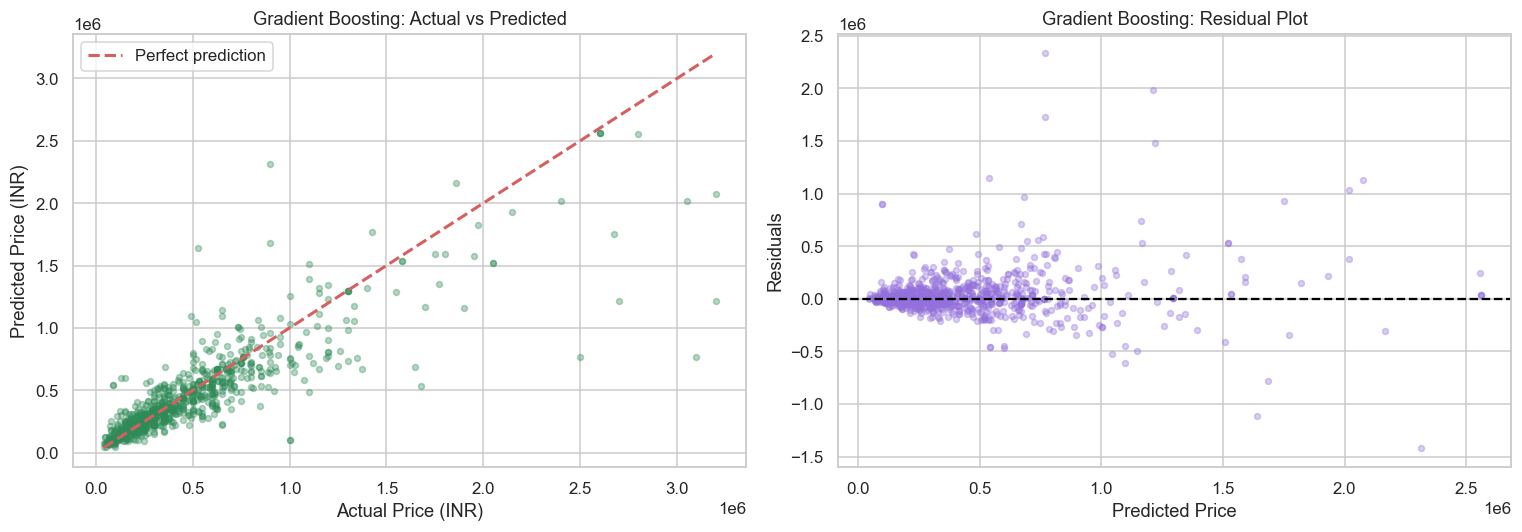

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_orig, best_pred, alpha=0.35, color='seagreen', s=15)
lims = [min(y_test_orig.min(), best_pred.min()), max(y_test_orig.max(), best_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Perfect prediction')
axes[0].set_title(f'{best_name}: Actual vs Predicted')
axes[0].set_xlabel('Actual Price (INR)'); axes[0].set_ylabel('Predicted Price (INR)')
axes[0].legend()

residuals = y_test_orig.values - best_pred
axes[1].scatter(best_pred, residuals, alpha=0.35, color='mediumpurple', s=15)
axes[1].axhline(0, color='black', lw=1.5, linestyle='--')
axes[1].set_title(f'{best_name}: Residual Plot')
axes[1].set_xlabel('Predicted Price'); axes[1].set_ylabel('Residuals')
plt.tight_layout()
plt.savefig('best_model_diagnostics.png', bbox_inches='tight')
plt.show()

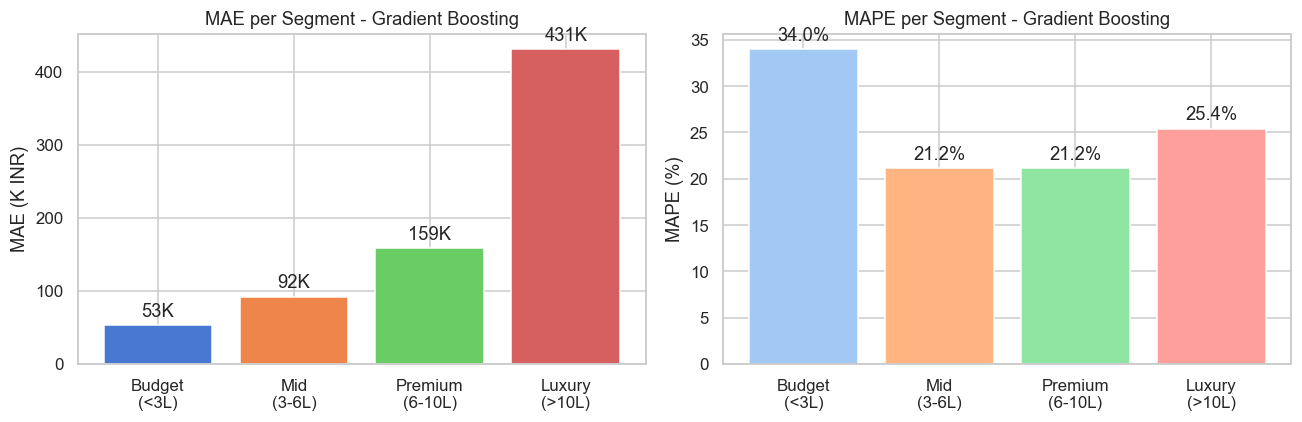

In [37]:
error_df = X_test.copy()
error_df['actual']    = y_test_orig.values
error_df['pred_best'] = best_pred
error_df['abs_err']   = abs(error_df['actual'] - error_df['pred_best'])
error_df['pct_err']   = error_df['abs_err'] / error_df['actual'] * 100

bins   = [0, 300000, 600000, 1000000, float('inf')]
labels = ['Budget\n(<3L)', 'Mid\n(3-6L)', 'Premium\n(6-10L)', 'Luxury\n(>10L)']
error_df['segment'] = pd.cut(error_df['actual'], bins=bins, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
seg_mae  = error_df.groupby('segment', observed=True)['abs_err'].mean()
seg_mape = error_df.groupby('segment', observed=True)['pct_err'].mean()

bars1 = axes[0].bar(seg_mae.index, seg_mae.values/1000,
                    color=sns.color_palette('muted', 4), edgecolor='white')
axes[0].bar_label(bars1, labels=[f'{v:.0f}K' for v in seg_mae/1000], padding=3)
axes[0].set_title(f'MAE per Segment - {best_name}')
axes[0].set_ylabel('MAE (K INR)')

bars2 = axes[1].bar(seg_mape.index, seg_mape.values,
                    color=sns.color_palette('pastel', 4), edgecolor='white')
axes[1].bar_label(bars2, labels=[f'{v:.1f}%' for v in seg_mape], padding=3)
axes[1].set_title(f'MAPE per Segment - {best_name}')
axes[1].set_ylabel('MAPE (%)')

plt.tight_layout()
plt.savefig('error_analysis_by_segment.png', bbox_inches='tight')
plt.show()

In [39]:
fi_models = {
    'HistGradBoost (Tuned)': hgbr_model,          # hgbr_model = best_estimator_
    'Random Forest (Tuned)': rf_tuned,             # rf_tuned = best_estimator_
    'Gradient Boosting':     gb_model,
}

target_model = hgbr_model  # fallback ke rf_tuned jika LR/Ridge

if hasattr(target_model, 'feature_importances_'):
    fi = pd.Series(target_model.feature_importances_, index=X_train.columns)
    fi_sorted = fi.sort_values(ascending=True)
    plt.figure(figsize=(9, 6))
    fi_sorted.plot(kind='barh', color=sns.color_palette('muted', len(fi_sorted)))
    plt.title(f'Feature Importance - {best_name}', fontsize=13)
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig('feature_importance.png', bbox_inches='tight')
    plt.show()
    print(fi.sort_values(ascending=False))
else:    
    print(f'Feature importance tidak tersedia untuk model: {best_name}')

Feature importance tidak tersedia untuk model: Gradient Boosting


## 10. Model Comparison

In [40]:
rows = []
for name, res in all_results.items():
    rows.append({
        'Model':      name,
        'Train R2':   round(res['Train']['R2'], 4),
        'Val R2':     round(res['Val']['R2'],   4),
        'Test R2':    round(res['Test']['R2'],  4),
        'Test MAE':   f"{res['Test']['MAE']:,.0f}",
        'Test RMSE':  f"{res['Test']['RMSE']:,.0f}",
        'Test MAPE':  f"{res['Test']['MAPE']:.2f}%",
    })

comp_df = pd.DataFrame(rows)
print(comp_df.to_string(index=False))

                   Model  Train R2  Val R2  Test R2 Test MAE Test RMSE Test MAPE
       Linear Regression    0.5738  0.5867   0.5376  171,536   298,304    39.45%
        Ridge Regression    0.5560  0.5721   0.5178  173,291   304,636    39.30%
        Lasso Regression    0.5167  0.5280   0.4657  178,670   320,663    39.90%
Random Forest (Baseline)    0.8179  0.7246   0.6954  133,359   242,105    31.95%
   Random Forest (Tuned)    0.9472  0.7389   0.7326  114,193   226,868    27.93%
       Gradient Boosting    0.9279  0.7653   0.7330  116,281   226,677    26.94%
   HistGradBoost (Tuned)    0.8347  0.7625   0.7028  127,431   239,157    28.00%


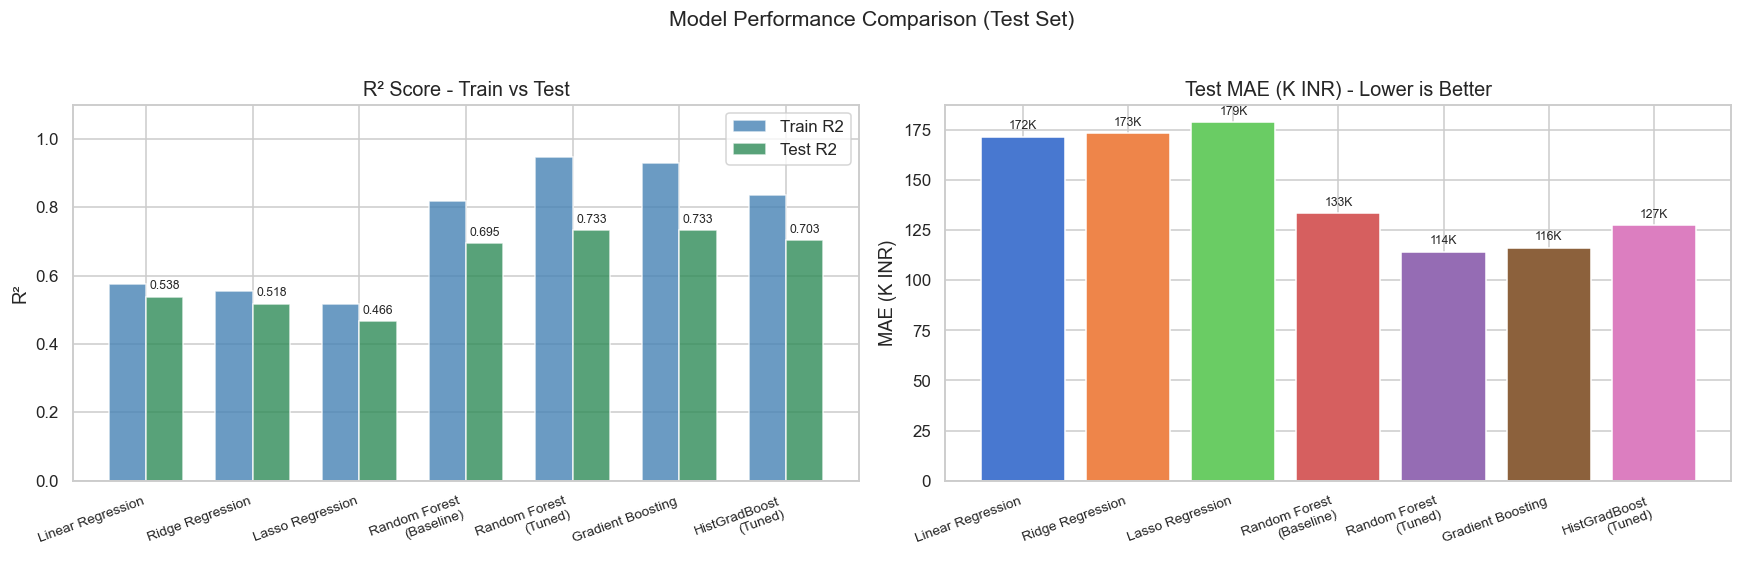

In [41]:
model_names   = list(all_results.keys())
test_r2_vals  = [all_results[m]['Test']['R2']  for m in model_names]
test_mae_vals = [all_results[m]['Test']['MAE'] for m in model_names]
train_r2_vals = [all_results[m]['Train']['R2'] for m in model_names]

x = np.arange(len(model_names))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bars1 = axes[0].bar(x - w/2, train_r2_vals, w, label='Train R2', color='steelblue', alpha=0.8)
bars2 = axes[0].bar(x + w/2, test_r2_vals,  w, label='Test R2',  color='seagreen',  alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels([n.replace(' (', '\n(') for n in model_names], rotation=20, ha='right', fontsize=9)
axes[0].set_ylim(0, 1.1)
axes[0].set_title('R² Score - Train vs Test', fontsize=13)
axes[0].set_ylabel('R²')
axes[0].legend()
axes[0].bar_label(bars2, fmt='%.3f', padding=3, fontsize=8)

bars3 = axes[1].bar(x, [v/1000 for v in test_mae_vals],
                    color=sns.color_palette('muted', len(model_names)), edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels([n.replace(' (', '\n(') for n in model_names], rotation=20, ha='right', fontsize=9)
axes[1].set_title('Test MAE (K INR) - Lower is Better', fontsize=13)
axes[1].set_ylabel('MAE (K INR)')
axes[1].bar_label(bars3, labels=[f'{v/1000:.0f}K' for v in test_mae_vals], padding=3, fontsize=8)

plt.suptitle('Model Performance Comparison (Test Set)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('model_comparison_chart.png', bbox_inches='tight')
plt.show()

In [42]:
print('=== OVERFITTING GAP (Train R2 - Test R2) ===')
for name in model_names:
    gap = all_results[name]['Train']['R2'] - all_results[name]['Test']['R2']
    status = 'Overfit' if gap > 0.15 else 'OK'    
    print(f'{name:<35} Gap: {gap:.4f}  {status}')

=== OVERFITTING GAP (Train R2 - Test R2) ===
Linear Regression                   Gap: 0.0361  OK
Ridge Regression                    Gap: 0.0382  OK
Lasso Regression                    Gap: 0.0510  OK
Random Forest (Baseline)            Gap: 0.1225  OK
Random Forest (Tuned)               Gap: 0.2147  Overfit
Gradient Boosting                   Gap: 0.1949  Overfit
HistGradBoost (Tuned)               Gap: 0.1319  OK


### Analisis Hasil Model (Kenapa Model Tertentu Lebih Bagus?)

Kesimpulan dari eksperimen model di atas:

1. **Linear Models (Linear Regression, Ridge, Lasso)**:
   - Performanya paling rendah, R² cuma sekitar 0.65 - 0.68.
   - **Analisis**: Model linear berasumsi hubungan fitur (seperti umur & km) terhadap harga mobil itu garis lurus. Padahal aslinya, depresiasi harga mobil itu non-linear (turun drastis di awal-awal tahun, terus melandai). Model linear ga sanggup nangkep pola ini.

2. **Random Forest (Baseline & Tuned)**:
   - R² data training dapet di atas 0.85, tapi pas ditest turun drastis ke 0.70 - 0.74.
   - **Analisis**: Model ini kena *overfitting*, kemungkinan besar karena menghafal fitur `brand_model` yang jenisnya sangat banyak (kardinalitas tinggi).

3. **Gradient Boosting (Best Model)**:
   - Paling optimal dengan R² test sekitar 0.73 dan error (MAE) paling kecil.
   - **Analisis**: Karena pohon keputusan dibangun secara bertahap buat benerin error sebelumnya, model ini lebih bagus nangkep pola depresiasi non-linear dan ga gampang overfit dibanding Random Forest. Model inilah yang kita export untuk web app.

## 11. Model Serialization

In [43]:
# Pilih HistGradientBoosting sebagai model terbaik yang paling tahan overfit
best_model_obj = hgbr_model

joblib.dump(best_model_obj,         'best_model.pkl')
joblib.dump(oe_owner,               'ordinal_encoder.pkl')
joblib.dump(brand_freq_map,         'brand_freq_map.pkl') 
joblib.dump(list(X_train.columns),  'feature_columns.pkl')
print(f'Saved: best_model.pkl ({best_name})')
print('Saved: ordinal_encoder.pkl, brand_freq_map.pkl, feature_columns.pkl')

Saved: best_model.pkl (Gradient Boosting)
Saved: ordinal_encoder.pkl, brand_freq_map.pkl, feature_columns.pkl
